# Maizels classifier trained on D3, D3.8, and D8

This notebook trains a PCA50 cell-type classifier using only cells from D3, D3.8, and D8, using an 85/15 training/validation split and no separate classifier test split. It preserves the architecture and checkpoint schema used by the flow-map code, reports performance at the best validation epoch, and compares its PC1/PC2 decision regions with the existing all-days classifier.

The decision-region figure is a two-dimensional slice through a 50-dimensional classifier: PC1 and PC2 vary over the plotted grid while PC3–PC50 are fixed to their full-population medians. Both classifiers receive exactly the same raw PCA50 grid.

In [1]:
# Imports and settings
import copy
import os
import random
import sys
from pathlib import Path

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "py" / "common" / "maizels.py").exists()
)
CACHE_DIR = ROOT / ".cache"
(CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
sys.path.insert(0, str(ROOT / "py"))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from common import maizels

plt.rcParams["text.usetex"] = False
plt.rcParams["figure.dpi"] = 120

TRAIN_DAYS = ("D3", "D3.8", "D8")
SEED = 0
BATCH_SIZE = 512
MAX_EPOCHS = 200
PATIENCE = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.20
GRID_SIZE = 320
BACKGROUND_MAX = 30_000

DATASET = ROOT / "celltype_classification_pca50_dataset.csv.gz"
CURRENT_CHECKPOINT = ROOT / "celltype_classifier_pca50.pt"
OUTPUT_DIR = ROOT / "outputs" / "maizels_classifier_d3_d3p8_d8"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NEW_CHECKPOINT = OUTPUT_DIR / "celltype_classifier_pca50_d3_d3p8_d8.pt"
NEW_NUMPY_CHECKPOINT = NEW_CHECKPOINT.with_suffix(".npz")
REGION_FIGURE = OUTPUT_DIR / "classifier_regions_pc1_pc2.png"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print("Repository:", ROOT)
print("Dataset:", DATASET)
print("Current classifier:", CURRENT_CHECKPOINT)
print("New classifier:", NEW_CHECKPOINT)
print("Device:", DEVICE)


Repository: /Users/harryamad/Desktop/drive/2026/flow-maps
Dataset: /Users/harryamad/Desktop/drive/2026/flow-maps/celltype_classification_pca50_dataset.csv.gz
Current classifier: /Users/harryamad/Desktop/drive/2026/flow-maps/celltype_classifier_pca50.pt
New classifier: /Users/harryamad/Desktop/drive/2026/flow-maps/outputs/maizels_classifier_d3_d3p8_d8/celltype_classifier_pca50_d3_d3p8_d8.pt
Device: mps


## Load the common PCA50 representation

The saved PCA coordinates are reused directly. PCA is not refitted, so the restricted and current classifiers operate in the same feature space.

In [2]:
for path in (DATASET, CURRENT_CHECKPOINT):
    if not path.exists():
        raise FileNotFoundError(path)

pc_columns = [f"PC{i}" for i in range(1, 51)]
frame = pd.read_csv(
    DATASET,
    usecols=["timepoint", "cell_annotation", *pc_columns],
)
X_all = frame[pc_columns].to_numpy(dtype=np.float32)
labels_all = frame["cell_annotation"].astype(str).to_numpy()
days_all = frame["timepoint"].astype(str).to_numpy()

current_classifier, current_class_names, current_mean, current_scale = (
    maizels.load_classifier(CURRENT_CHECKPOINT)
)
class_names = list(current_class_names)
class_to_id = {name: index for index, name in enumerate(class_names)}

if set(labels_all) != set(class_names):
    raise ValueError(
        "Dataset/checkpoint class mismatch: "
        f"dataset={sorted(set(labels_all))}, checkpoint={sorted(class_names)}"
    )

selected_mask = np.isin(days_all, TRAIN_DAYS)
X_selected = X_all[selected_mask]
labels_selected = labels_all[selected_mask]
days_selected = days_all[selected_mask]
y_selected = np.asarray([class_to_id[name] for name in labels_selected], dtype=np.int64)

day_order = sorted(set(days_all), key=maizels.parse_timepoint)
counts = pd.crosstab(
    pd.Categorical(days_all, categories=day_order),
    pd.Categorical(labels_all, categories=class_names),
)
display(counts)
print(f"Selected {len(X_selected):,} of {len(X_all):,} cells from {TRAIN_DAYS}.")
display(counts.loc[list(TRAIN_DAYS)].sum().rename("selected-day total").to_frame().T)

selected_class_counts = np.bincount(y_selected, minlength=len(class_names))
if np.any(selected_class_counts < 4):
    too_small = {
        class_names[i]: int(count)
        for i, count in enumerate(selected_class_counts)
        if count < 4
    }
    raise ValueError(f"Too few selected-day cells for stratification: {too_small}")


col_0,Early_Neural,FP,MN,Mesoderm,NMP,Neural,V3,p3,pMN
row_0,,,,,,,,,
D3,3,0,0,276,2921,3,0,0,0
D3.2,475,0,0,207,2132,10,0,0,0
D3.4,1105,0,0,373,1743,49,0,0,0
D3.6,1666,0,0,549,850,687,0,0,0
D3.8,839,0,0,529,408,1595,0,0,0
D4,29,0,15,1545,100,3294,0,0,6
D5,3,32,1125,3461,0,32,3,18,2575
D6,0,305,771,1523,1,0,58,244,1899
D7,0,732,679,1203,1,0,1407,1813,1663


Selected 10,330 of 44,713 cells from ('D3', 'D3.8', 'D8').


col_0,Early_Neural,FP,MN,Mesoderm,NMP,Neural,V3,p3,pMN
selected-day total,842,268,151,1163,3329,1598,1574,1055,350


## Make a leakage-safe 85/15 training/validation split

Only selected-day cells enter these splits. The scaler is fitted on the 85% training split alone; the remaining 15% is used for validation and model selection. Excluded days are retained solely for the later out-of-timepoint diagnostic.

In [ ]:
indices = np.arange(len(X_selected))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    stratify=y_selected,
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_selected[train_idx]).astype(np.float32)
X_val = scaler.transform(X_selected[val_idx]).astype(np.float32)
y_train = y_selected[train_idx]
y_val = y_selected[val_idx]

split_summary = pd.DataFrame(
    {
        "train": np.bincount(y_train, minlength=len(class_names)),
        "validation": np.bincount(y_val, minlength=len(class_names)),
    },
    index=class_names,
)
display(split_summary)
print("Split sizes:", {"train": len(train_idx), "validation": len(val_idx)})


## Train the restricted classifier

This is the same 50→128→64→9 MLP used by the current checkpoint. Inverse-frequency class weights are important because MN, FP, and pMN are much rarer than NMP or Neural in the selected days.

In [ ]:
class CellTypeMLP(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, values):
        return self.net(values)


def make_loader(values, targets, shuffle=False):
    generator = torch.Generator().manual_seed(SEED) if shuffle else None
    dataset = TensorDataset(torch.from_numpy(values), torch.from_numpy(targets))
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        drop_last=shuffle and len(dataset) % BATCH_SIZE == 1,
        generator=generator,
    )


train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)

def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    true_parts, pred_parts = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(xb)
            true_parts.append(yb.cpu().numpy())
            pred_parts.append(logits.argmax(dim=1).cpu().numpy())
    truth = np.concatenate(true_parts)
    prediction = np.concatenate(pred_parts)
    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(truth, prediction),
        "balanced_accuracy": balanced_accuracy_score(truth, prediction),
        "macro_f1": f1_score(truth, prediction, average="macro", zero_division=0),
    }


set_seed()
model = CellTypeMLP(50, len(class_names), DROPOUT).to(DEVICE)
train_counts = np.bincount(y_train, minlength=len(class_names)).astype(np.float32)
class_weights = len(y_train) / (len(class_names) * train_counts)
criterion = nn.CrossEntropyLoss(
    weight=torch.as_tensor(class_weights, dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

best_state = None
best_epoch = 0
best_val_accuracy = -float("inf")
best_val_loss = float("inf")
epochs_without_improvement = 0
history_rows = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    train_true, train_pred = [], []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
        train_true.append(yb.detach().cpu().numpy())
        train_pred.append(logits.argmax(dim=1).detach().cpu().numpy())

    train_true = np.concatenate(train_true)
    train_pred = np.concatenate(train_pred)
    train_metrics = {
        "loss": total_loss / len(train_loader.dataset),
        "accuracy": accuracy_score(train_true, train_pred),
        "balanced_accuracy": balanced_accuracy_score(train_true, train_pred),
        "macro_f1": f1_score(train_true, train_pred, average="macro", zero_division=0),
    }
    val_metrics = evaluate_loader(model, val_loader, criterion)
    history_rows.append({
        "epoch": epoch,
        **{f"train_{key}": value for key, value in train_metrics.items()},
        **{f"val_{key}": value for key, value in val_metrics.items()},
    })

    improved = (
        val_metrics["accuracy"] > best_val_accuracy + 1e-12
        or (
            np.isclose(val_metrics["accuracy"], best_val_accuracy)
            and val_metrics["loss"] < best_val_loss - 1e-5
        )
    )
    if improved:
        best_val_accuracy = val_metrics["accuracy"]
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"epoch {epoch:03d} | train loss={train_metrics['loss']:.4f} "
            f"macro_f1={train_metrics['macro_f1']:.4f} | "
            f"val loss={val_metrics['loss']:.4f} macro_f1={val_metrics['macro_f1']:.4f}"
        )
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
        break

if best_state is None:
    raise RuntimeError("Training did not produce a checkpoint.")
model.load_state_dict(best_state)
best_validation_metrics = evaluate_loader(model, val_loader, criterion)
history = pd.DataFrame(history_rows)
display(history.tail())
print(
    f"Best epoch: {best_epoch}; validation accuracy: "
    f"{best_validation_metrics['accuracy']:.4%}"
)


## Evaluate validation and excluded-day performance

The selected-day validation split is used for model selection, so its score is reported as validation performance rather than as a test estimate. The current all-days model is shown for context. Excluded-day metrics are diagnostic only and are not used for classifier fitting or model selection.

In [3]:
def predict_torch_raw(model, raw_values, fitted_scaler, batch_size=8192):
    scaled = fitted_scaler.transform(raw_values).astype(np.float32)
    predictions = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(scaled), batch_size):
            logits = model(torch.from_numpy(scaled[start:start + batch_size]).to(DEVICE))
            predictions.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(predictions)


new_val_pred = predict_torch_raw(model, X_selected[val_idx], scaler)
current_val_names, _, _ = maizels.classifier_predictions(
    current_classifier,
    current_class_names,
    current_mean,
    current_scale,
    X_selected[val_idx],
    batch_size=8192,
)
current_val_pred = np.asarray([class_to_id[name] for name in current_val_names])

def metric_row(name, truth, prediction):
    observed_classes = np.unique(truth)
    return {
        "classifier": name,
        "accuracy": accuracy_score(truth, prediction),
        "balanced_accuracy": float(np.mean([
            np.mean(prediction[truth == class_id] == class_id)
            for class_id in observed_classes
        ])),
        "macro_f1": f1_score(
            truth,
            prediction,
            labels=observed_classes,
            average="macro",
            zero_division=0,
        ),
    }

selected_validation_metrics = pd.DataFrame([
    metric_row("Current all-days (context only)", y_val, current_val_pred),
    metric_row("Restricted D3/D3.8/D8", y_val, new_val_pred),
]).set_index("classifier")
display(selected_validation_metrics)

restricted_report = pd.DataFrame(
    classification_report(
        y_val,
        new_val_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).T
display(restricted_report)

excluded_mask = ~selected_mask
excluded_X = X_all[excluded_mask]
excluded_y = np.asarray([class_to_id[name] for name in labels_all[excluded_mask]])
excluded_days = days_all[excluded_mask]
new_excluded_pred = predict_torch_raw(model, excluded_X, scaler)
current_excluded_names, _, _ = maizels.classifier_predictions(
    current_classifier,
    current_class_names,
    current_mean,
    current_scale,
    excluded_X,
    batch_size=8192,
)
current_excluded_pred = np.asarray([class_to_id[name] for name in current_excluded_names])

excluded_rows = []
for day in sorted(set(excluded_days), key=maizels.parse_timepoint):
    mask = excluded_days == day
    for name, prediction in (
        ("Current all-days", current_excluded_pred),
        ("Restricted D3/D3.8/D8", new_excluded_pred),
    ):
        row = metric_row(name, excluded_y[mask], prediction[mask])
        row.update({"day": day, "n_cells": int(mask.sum())})
        excluded_rows.append(row)

excluded_day_metrics = pd.DataFrame(excluded_rows).set_index(["day", "classifier"])
display(excluded_day_metrics)


NameError: name 'model' is not defined

In [ ]:
# Training history and restricted-model confusion matrix.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["val_loss"], label="validation")
axes[0].axvline(best_epoch, color="0.35", linestyle="--", linewidth=1)
axes[0].set(title="Weighted cross-entropy", xlabel="Epoch", ylabel="Loss")
axes[0].legend(frameon=False)

axes[1].plot(history["epoch"], history["train_macro_f1"], label="train")
axes[1].plot(history["epoch"], history["val_macro_f1"], label="validation")
axes[1].axvline(best_epoch, color="0.35", linestyle="--", linewidth=1)
axes[1].set(title="Macro F1", xlabel="Epoch", ylabel="Macro F1", ylim=(0, 1.02))
axes[1].legend(frameon=False)

matrix = confusion_matrix(y_val, new_val_pred, labels=np.arange(len(class_names)))
image = axes[2].imshow(matrix, cmap="Blues")
axes[2].set_xticks(range(len(class_names)), class_names, rotation=60, ha="right")
axes[2].set_yticks(range(len(class_names)), class_names)
axes[2].set(title="Restricted classifier: validation split", xlabel="Predicted", ylabel="True")
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)
fig.tight_layout()
diagnostic_figure = OUTPUT_DIR / "training_diagnostics.png"
fig.savefig(diagnostic_figure, dpi=200, bbox_inches="tight")
plt.show()


## Export a flow-map-compatible checkpoint

Both PyTorch and NumPy checkpoints are written under outputs, leaving the existing all-days classifier untouched.

In [ ]:
try:
    current_payload = torch.load(CURRENT_CHECKPOINT, map_location="cpu", weights_only=False)
except TypeError:
    current_payload = torch.load(CURRENT_CHECKPOINT, map_location="cpu")
current_metadata = current_payload.get("metadata", {})

model = model.to("cpu").eval()
cpu_state = {
    key: value.detach().cpu().clone()
    for key, value in model.state_dict().items()
}
numpy_state = {
    key: value.detach().cpu().numpy()
    for key, value in cpu_state.items()
    if not key.endswith("num_batches_tracked")
}

restricted_metrics = selected_validation_metrics.loc["Restricted D3/D3.8/D8"].to_dict()
metadata = {
    "class_names": class_names,
    "selected_genes": current_metadata.get("selected_genes", []),
    "n_pcs": 50,
    "scaler_mean": scaler.mean_.astype(float).tolist(),
    "scaler_scale": scaler.scale_.astype(float).tolist(),
    "training_timepoints": list(TRAIN_DAYS),
    "excluded_timepoints": [day for day in day_order if day not in TRAIN_DAYS],
    "dataset": str(DATASET),
    "seed": SEED,
    "best_epoch": int(best_epoch),
    "split_sizes": {
        "train": len(train_idx),
        "validation": len(val_idx),
    },
    "selection_metric": "validation_accuracy",
    "best_validation_metrics": {
        key: float(value) for key, value in restricted_metrics.items()
    },
}

torch.save({"model_state_dict": cpu_state, "metadata": metadata}, NEW_CHECKPOINT)
np.savez_compressed(
    NEW_NUMPY_CHECKPOINT,
    class_names=np.asarray(class_names),
    scaler_mean=scaler.mean_.astype(np.float32),
    scaler_scale=scaler.scale_.astype(np.float32),
    n_pcs=np.asarray(50, dtype=np.int64),
    training_timepoints=np.asarray(TRAIN_DAYS),
    **numpy_state,
)

history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
restricted_report.to_csv(OUTPUT_DIR / "selected_day_validation_classification_report.csv")
selected_validation_metrics.to_csv(OUTPUT_DIR / "selected_day_validation_metrics.csv")
excluded_day_metrics.to_csv(OUTPUT_DIR / "excluded_day_metrics.csv")

# Verify that the NumPy export and PyTorch model produce the same logits.
verification_x = X_val[: min(256, len(X_val))]
with torch.no_grad():
    torch_logits = model(torch.from_numpy(verification_x)).numpy()
numpy_logits = maizels.NumpyCellTypeMLP(numpy_state).predict_logits(verification_x)
max_abs_error = float(np.max(np.abs(torch_logits - numpy_logits)))
if not np.allclose(torch_logits, numpy_logits, rtol=1e-5, atol=1e-5):
    raise RuntimeError(f"NumPy export mismatch: max absolute error={max_abs_error:.3g}")

model = model.to(DEVICE)
print("Saved:", NEW_CHECKPOINT)
print("Saved:", NEW_NUMPY_CHECKPOINT)
print(f"Best validation accuracy: {restricted_metrics['accuracy']:.4%}")
print(f"NumPy export maximum absolute logit error: {max_abs_error:.3g}")


## Compare PC1/PC2 classifier regions

The coloured field shows the most probable class. Small dark points show the density of all observed cells. Because the classifiers use all 50 PCs, this is a common slice rather than a complete projection of either decision function: PC3–PC50 are fixed to their median values across the full dataset.

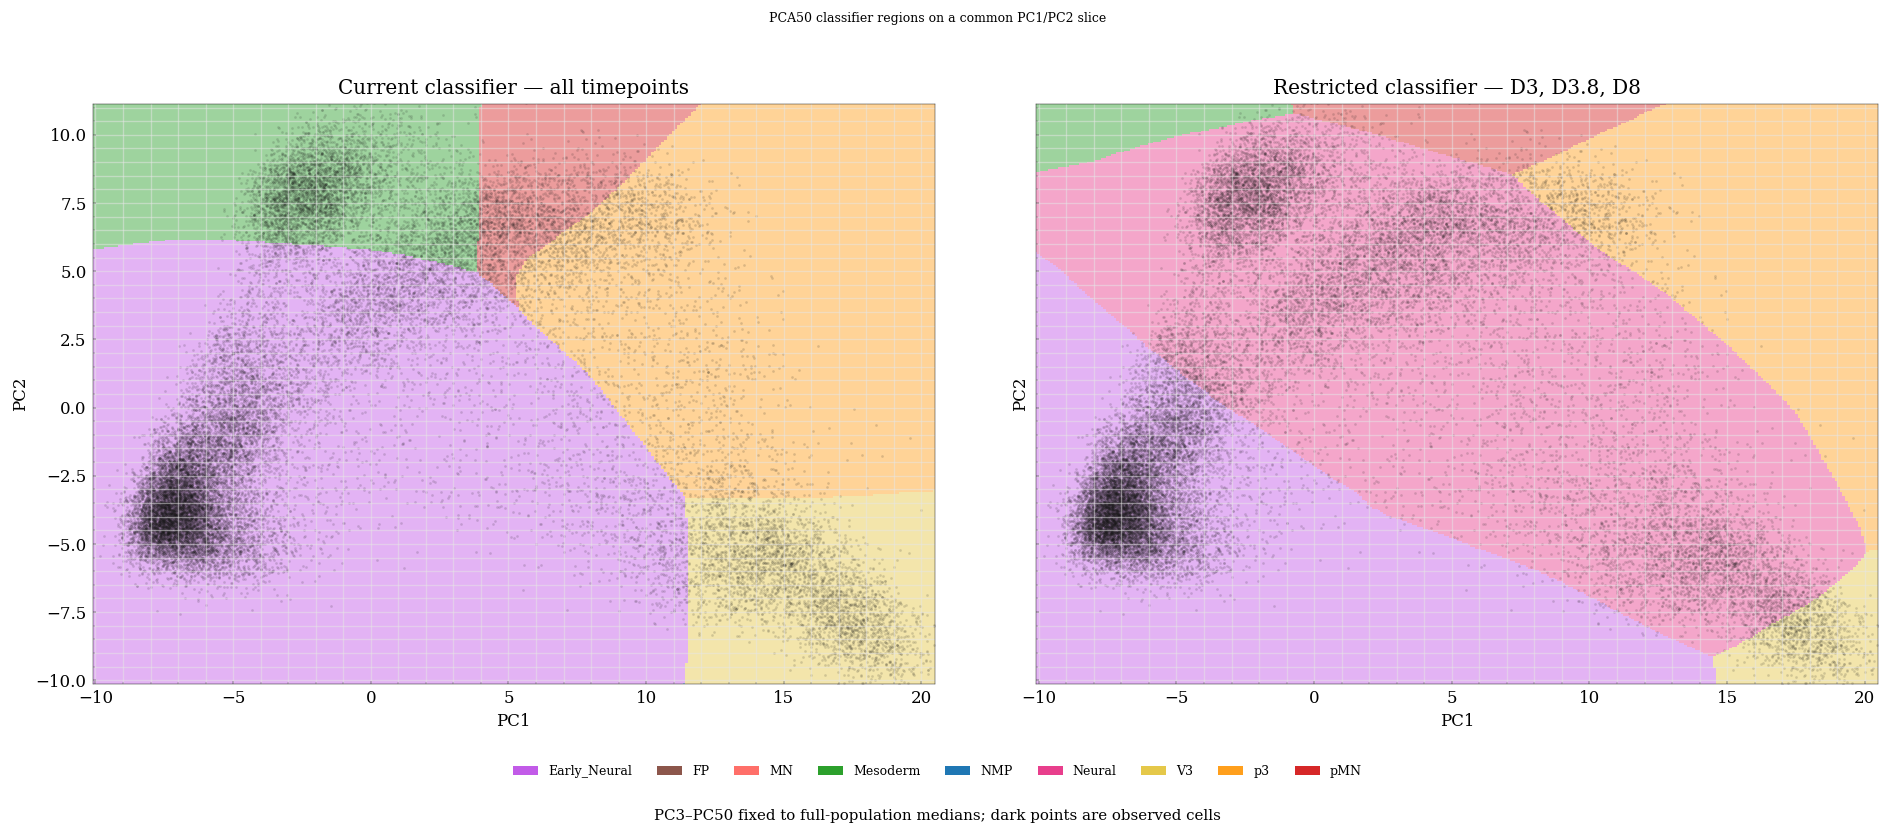

Saved: /Users/harryamad/Desktop/drive/2026/flow-maps/outputs/maizels_classifier_d3_d3p8_d8/classifier_regions_pc1_pc2.png


In [4]:
restricted_classifier, restricted_class_names, restricted_mean, restricted_scale = (
    maizels.load_classifier(NEW_CHECKPOINT)
)
if list(restricted_class_names) != class_names:
    raise ValueError("Restricted classifier class order differs from the current classifier.")

CELLTYPE_COLORS = {
    "Early_Neural": "#c25be8",
    "FP": "#8c564b",
    "MN": "#ff6f69",
    "Mesoderm": "#2ca02c",
    "NMP": "#1f77b4",
    "Neural": "#e83e8c",
    "V3": "#e5c849",
    "p3": "#ff9f1c",
    "pMN": "#d62728",
}
region_cmap = ListedColormap([CELLTYPE_COLORS[name] for name in class_names])
region_norm = BoundaryNorm(np.arange(-0.5, len(class_names) + 0.5), len(class_names))

lower = np.quantile(X_all[:, :2], 0.005, axis=0)
upper = np.quantile(X_all[:, :2], 0.995, axis=0)
padding = 0.05 * (upper - lower)
lower, upper = lower - padding, upper + padding
pc1_values = np.linspace(lower[0], upper[0], GRID_SIZE, dtype=np.float32)
pc2_values = np.linspace(lower[1], upper[1], GRID_SIZE, dtype=np.float32)
grid_pc1, grid_pc2 = np.meshgrid(pc1_values, pc2_values)

slice_reference = np.median(X_all, axis=0).astype(np.float32)
grid_50d = np.repeat(slice_reference[None, :], grid_pc1.size, axis=0)
grid_50d[:, 0] = grid_pc1.ravel()
grid_50d[:, 1] = grid_pc2.ravel()

def predict_region(classifier, names, mean, scale):
    predicted_names, top_probability, _ = maizels.classifier_predictions(
        classifier,
        names,
        mean,
        scale,
        grid_50d,
        batch_size=8192,
    )
    predicted_ids = np.asarray([class_to_id[name] for name in predicted_names])
    return predicted_ids.reshape(grid_pc1.shape), top_probability.reshape(grid_pc1.shape)

current_region, current_region_probability = predict_region(
    current_classifier, current_class_names, current_mean, current_scale
)
restricted_region, restricted_region_probability = predict_region(
    restricted_classifier, restricted_class_names, restricted_mean, restricted_scale
)

def stratified_sample_indices(labels, maximum, seed):
    if len(labels) <= maximum:
        return np.arange(len(labels))
    rng = np.random.default_rng(seed)
    chosen = []
    for label in class_names:
        candidates = np.flatnonzero(labels == label)
        count = max(1, round(maximum * len(candidates) / len(labels)))
        chosen.extend(rng.choice(candidates, min(count, len(candidates)), replace=False))
    chosen = np.asarray(chosen, dtype=int)
    if len(chosen) > maximum:
        chosen = rng.choice(chosen, maximum, replace=False)
    return np.sort(chosen)

background_idx = stratified_sample_indices(labels_all, BACKGROUND_MAX, SEED + 23)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
panels = [
    (axes[0], current_region, "Current classifier — all timepoints"),
    (axes[1], restricted_region, "Restricted classifier — D3, D3.8, D8"),
]
for axis, region, title in panels:
    axis.pcolormesh(
        grid_pc1,
        grid_pc2,
        region,
        cmap=region_cmap,
        norm=region_norm,
        shading="auto",
        alpha=0.46,
        rasterized=True,
    )
    axis.scatter(
        X_all[background_idx, 0],
        X_all[background_idx, 1],
        s=2.5,
        c="#171717",
        alpha=0.16,
        linewidths=0,
        rasterized=True,
    )
    axis.set(
        title=title,
        xlabel="PC1",
        ylabel="PC2",
        xlim=(lower[0], upper[0]),
        ylim=(lower[1], upper[1]),
    )

legend_handles = [
    Patch(facecolor=CELLTYPE_COLORS[name], edgecolor="none", label=name)
    for name in class_names
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(class_names),
    frameon=False,
    bbox_to_anchor=(0.5, 0.055),
)
fig.suptitle("PCA50 classifier regions on a common PC1/PC2 slice", y=0.98)
fig.text(
    0.5,
    0.018,
    "PC3–PC50 fixed to full-population medians; dark points are observed cells",
    ha="center",
    fontsize=9,
)
fig.subplots_adjust(left=0.06, right=0.99, bottom=0.18, top=0.87, wspace=0.12)
fig.savefig(REGION_FIGURE, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", REGION_FIGURE)


## Quantify how much the classifiers differ

Grid agreement describes only the displayed median slice. Observed-cell agreement uses each cell's complete PCA50 vector and is therefore the more biologically relevant comparison.

In [5]:
current_all_names, current_all_probability, _ = maizels.classifier_predictions(
    current_classifier,
    current_class_names,
    current_mean,
    current_scale,
    X_all,
    batch_size=8192,
)
restricted_all_names, restricted_all_probability, _ = maizels.classifier_predictions(
    restricted_classifier,
    restricted_class_names,
    restricted_mean,
    restricted_scale,
    X_all,
    batch_size=8192,
)

agreement_rows = []
for day in day_order:
    mask = days_all == day
    agreement_rows.append({
        "day": day,
        "n_cells": int(mask.sum()),
        "classifier_agreement": float(
            np.mean(current_all_names[mask] == restricted_all_names[mask])
        ),
        "current_accuracy": float(np.mean(current_all_names[mask] == labels_all[mask])),
        "restricted_accuracy": float(np.mean(restricted_all_names[mask] == labels_all[mask])),
        "current_mean_top_probability": float(np.mean(current_all_probability[mask])),
        "restricted_mean_top_probability": float(np.mean(restricted_all_probability[mask])),
    })

agreement_summary = pd.DataFrame(agreement_rows).set_index("day")
display(agreement_summary)
print(f"Decision-grid agreement: {np.mean(current_region == restricted_region):.2%}")
print(f"Observed-cell agreement: {np.mean(current_all_names == restricted_all_names):.2%}")
agreement_summary.to_csv(OUTPUT_DIR / "classifier_agreement_by_day.csv")


,n_cells,classifier_agreement,current_accuracy,restricted_accuracy,current_mean_top_probability,restricted_mean_top_probability
day,,,,,,
D3,3203,0.990322,0.990009,0.996878,0.990691,0.995351
D3.2,2824,0.867918,0.957153,0.847025,0.958578,0.921050
D3.4,3270,0.885015,0.946789,0.862080,0.944342,0.921607
D3.6,3752,0.902452,0.917644,0.873667,0.911707,0.930743
D3.8,3371,0.930881,0.922278,0.971522,0.908134,0.962437
D4,4989,0.925837,0.977751,0.918621,0.975570,0.961671
D5,7249,0.669058,0.991723,0.666713,0.987919,0.902049
D6,4801,0.930848,0.979588,0.923558,0.974627,0.962739
D7,7498,0.950920,0.974927,0.939851,0.971946,0.974983


Decision-grid agreement: 49.39%
Observed-cell agreement: 89.01%
